In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_2_Prostate/notebooks/Post-hoc_Analysis


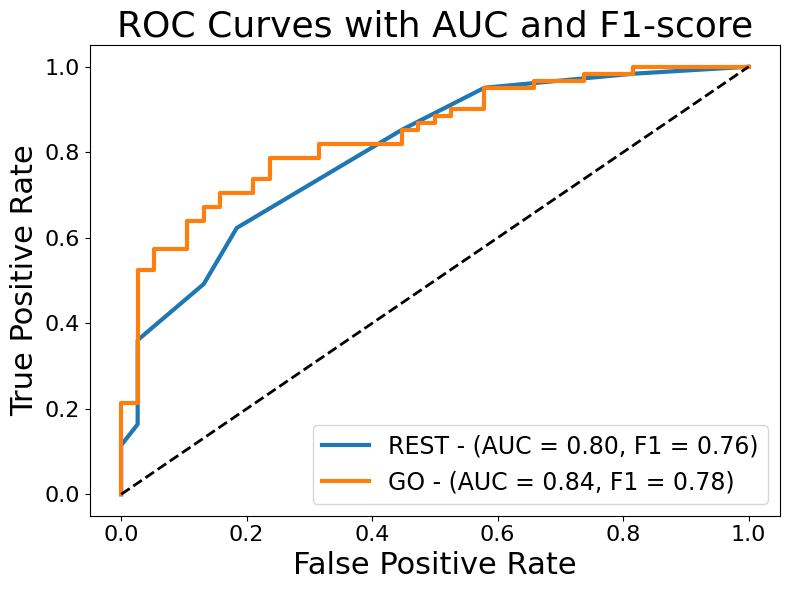

In [2]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import auc
import pandas as pd

# List of files to process
file_paths = [
    "./PASNet/Output/REST/roc_curve_data_Validation.txt",
    "./PASNet/Output/GO/roc_curve_data_Validation.txt",
]

# Manually assign F1 scores corresponding to each file
f1_scores = [0.76, 0.78]

# Plotting
plt.figure(figsize=(8, 6))

for file_path, f1 in zip(file_paths, f1_scores):
    # Read the file (tab-separated, skipping comment lines)
    df = pd.read_csv(file_path, sep="\t", comment='#', names=["FPR", "TPR"])

    # Calculate AUC
    curve_auc = auc(df["FPR"], df["TPR"])

    # Generate label from file path, including F1-score
    method = os.path.basename(os.path.dirname(file_path))   # REST or GO
    dataset = os.path.splitext(os.path.basename(file_path))[0].replace("roc_curve_data_", "")
    label = f"{method} - (AUC = {curve_auc:.2f}, F1 = {f1:.2f})"

    # Plot the ROC curve with thicker line
    plt.plot(df["FPR"], df["TPR"], label=label, linewidth=3)

# Diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=2)

# Plot settings with larger labels and title
plt.xlabel("False Positive Rate", fontsize=22)
plt.ylabel("True Positive Rate", fontsize=22)
plt.title("ROC Curves with AUC and F1-score", fontsize=26)
plt.legend(loc="lower right", fontsize=17, frameon=True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Remove grid and background "table"
plt.grid(False)
plt.gca().set_facecolor('white')

plt.tight_layout()

# Save the figure
plt.savefig("../../figures/AUC_ROC.png", dpi=600)

# Display the plot
plt.show()
